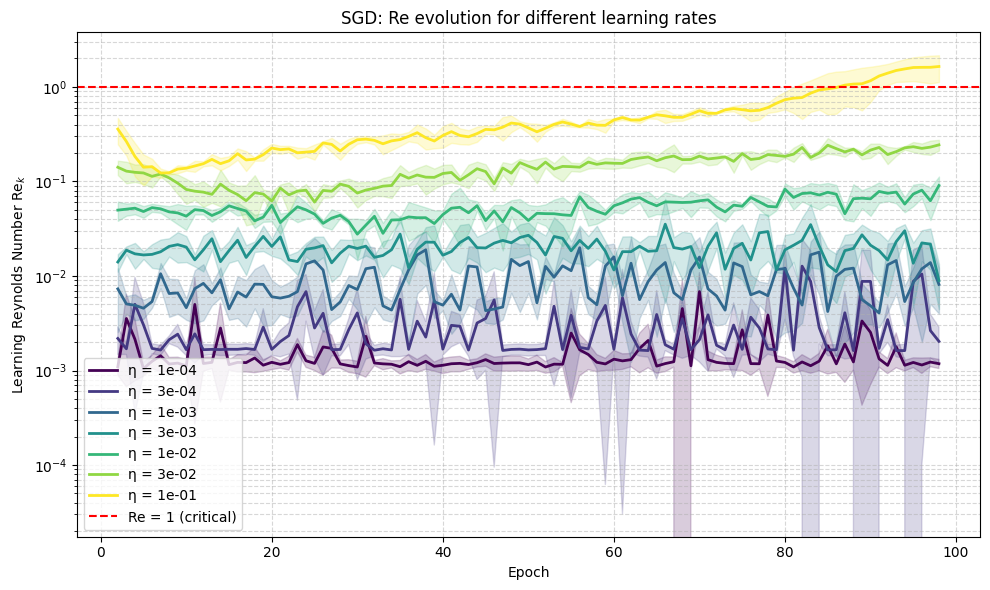

Final average Re (last 10 epochs):
  η = 1e-04 : Re ≈ 0.002
  η = 3e-04 : Re ≈ 0.005
  η = 1e-03 : Re ≈ 0.009
  η = 3e-03 : Re ≈ 0.020
  η = 1e-02 : Re ≈ 0.073
  η = 3e-02 : Re ≈ 0.219
  η = 1e-01 : Re ≈ 1.446


In [ ]:
Z# =============================================================================
# Learning Reynolds Number for SGD: Re(k) over training epochs
# This code trains a small MLP with SGD at various learning rates,
# extracts the discrete trajectory, computes velocity v_k and acceleration a_k,
# and calculates the instantaneous Learning Reynolds Number:
#     Re_k = ||a_k|| / (||v_k|| + eps)
# The plot shows how Re evolves with epoch for each learning rate.
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. Define a simple MLP
# ---------------------------
class SimpleNet(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=1):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ---------------------------
# 2. Generate synthetic data (fixed for all runs)
# ---------------------------
torch.manual_seed(42)
np.random.seed(42)

input_dim = 10
output_dim = 1
n_samples = 200
X = torch.randn(n_samples, input_dim)
y = torch.randn(n_samples, output_dim)

# ---------------------------
# 3. Training function: returns Re trajectory and final loss
# ---------------------------
def train_and_get_Re(lr, epochs=100, seed=0):
    # Set seeds for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SimpleNet()
    loss_fn = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    theta_history = []
    grad_history = []   # stores -∇L(θ_k)
    loss_history = []

    model.train()
    for k in range(epochs):
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()

        # Record parameters and negative gradient
        theta_k = torch.cat([p.data.view(-1) for p in model.parameters()])
        grad_k = torch.cat([p.grad.view(-1) for p in model.parameters()])
        theta_history.append(theta_k.cpu().numpy())
        grad_history.append(-grad_k.cpu().numpy())   # store -∇L
        loss_history.append(loss.item())

        optimizer.step()

    # Convert to numpy arrays
    theta_traj = np.array(theta_history)   # (epochs, D)
    grad_traj = np.array(grad_history)     # (epochs, D)

    # Compute velocities and accelerations
    # v_k = θ_{k+1} - θ_k   for k = 0 .. epochs-2
    v_traj = np.diff(theta_traj, axis=0)   # (epochs-1, D)
    # a_k = v_{k+1} - v_k   for k = 0 .. epochs-3
    a_traj = np.diff(v_traj, axis=0)       # (epochs-2, D)

    # Align so that the equation holds at θ_{k+1}:
    # we need v_k, a_k and -∇L(θ_{k+1})
    # Available indices: v[0..epochs-2], a[0..epochs-3], grad[0..epochs-1]
    # We can use k from 1 to epochs-2 (inclusive) such that:
    #   v_k = v_traj[k]            (since v_traj index = k)
    #   a_k = a_traj[k]            (since a_traj index = k)
    #   -∇L(θ_{k+1}) = grad_traj[k+1]
    # So we slice from k=1 to k=epochs-2  (exclusive of the last)
    # That gives N = epochs-3 time points.
    aligned_v = v_traj[1:-1]          # (epochs-3, D)
    aligned_a = a_traj[1:]            # (epochs-3, D)  because a_traj has length epochs-2, we take indices 1..end
    # Wait: a_traj[1:] gives indices 1..epochs-3, which is correct.
    # Let's check lengths:
    # v_traj length = epochs-1, we take 1..epochs-2 => length epochs-3
    # a_traj length = epochs-2, we take 1..epochs-3 => length epochs-3
    # grad_traj length = epochs, we take 2..epochs-1 => length epochs-2? Actually we need grad at k+1 where k goes 1..epochs-2 => k+1 goes 2..epochs-1 => indices 2 to epochs-1 inclusive => length epochs-2? That's one too many.
    # Let's carefully align.
    # We want for each k from 1 to epochs-2 (inclusive):
    #   v_k = v_traj[k] (because v_traj[k] = θ_{k+1} - θ_k)
    #   a_k = a_traj[k] (because a_traj[k] = v_{k+1} - v_k = (θ_{k+2}-θ_{k+1}) - (θ_{k+1}-θ_k))
    #   -∇L(θ_{k+1}) = grad_traj[k+1]
    # So k ranges 1..epochs-2, number of points = epochs-2.
    # But a_traj has length epochs-2 (indices 0..epochs-3). For k up to epochs-2, a_traj[k] is valid only if k <= epochs-3. So k max = epochs-3.
    # Let's choose k from 1 to epochs-3 inclusive -> number of points = epochs-3.
    # Then we have:
    #   v_k = v_traj[1:epochs-2]   (indices 1..epochs-3) length epochs-3
    #   a_k = a_traj[1:epochs-2]   (indices 1..epochs-3) length epochs-3 (since a_traj indices 0..epochs-3)
    #   grad at θ_{k+1} = grad_traj[2:epochs-1]  (indices 2..epochs-2?) Let's compute:
    #   for k=1 => grad_traj[2]; for k=epochs-3 => grad_traj[epochs-2]? That would be index epochs-2? grad_traj indices 0..epochs-1, so epochs-2 is valid.
    #   So we need grad_traj[2:epochs-2]? That gives indices 2..epochs-3? Not matching.
    # Let's re-evaluate: a_traj length = epochs-2 (indices 0..epochs-3). We take a_traj[1:epochs-2]? That would be indices 1..epochs-3, length epochs-3. Good.
    # Then v_traj length = epochs-1 (indices 0..epochs-2). We take v_traj[1:epochs-2] -> indices 1..epochs-3, length epochs-3. Good.
    # grad_traj length = epochs. We need grad_traj[2:epochs-1] -> indices 2..epochs-2, length epochs-3 (since epochs-2 - 2 = epochs-4? Let's compute: start=2, stop=epochs-1 exclusive => indices 2,3,...,epochs-2 => count = (epochs-2) - 2 + 1 = epochs-3. Perfect.
    # So we take:
    # aligned_v = v_traj[1:-1]? v_traj[1:-1] gives indices 1..epochs-3? Since -1 means last index epochs-2, so 1:-1 -> indices 1..epochs-3, length epochs-3. Good.
    # aligned_a = a_traj[1:]? a_traj[1:] gives indices 1..epochs-3, length epochs-3. Good.
    # aligned_grad = grad_traj[2:-1]? grad_traj[2:-1] gives indices 2..epochs-2, length epochs-3. Good.
    aligned_v = v_traj[1:-1]
    aligned_a = a_traj[1:]   # same length as aligned_v
    aligned_grad = grad_traj[2:-1]

    # Compute per-step Re = ||a_k|| / (||v_k|| + eps)
    eps = 1e-12
    v_norms = np.linalg.norm(aligned_v, axis=1) + eps
    a_norms = np.linalg.norm(aligned_a, axis=1)
    Re_k = a_norms / v_norms

    # We also want to associate these Re with epoch numbers.
    # The first aligned point corresponds to k=1, so epoch index (starting from 0) is k+1? Actually we started training at epoch 0.
    # Our aligned_v[0] corresponds to v_1 (velocity from θ_1 to θ_2), aligned_a[0] corresponds to a_1, and gradient at θ_2.
    # So the first Re is associated with epoch 2 (the θ_{k+1} index). We'll set epoch indices as 2,3,...,epochs-2? Actually len(Re_k) = epochs-3, so epochs range from 2 to epochs-2? For epochs=100, we have indices 2..98? Let's just create an array of epoch numbers for plotting.
    # We'll start from epoch = 2 (since we need θ_2) and go to epoch = epochs-2? Actually the last aligned point uses gradient at θ_{epochs-1}? grad_traj[epochs-2] corresponds to -∇L(θ_{epochs-2})? Wait careful.
    # We have grad_traj[k] = -∇L(θ_k). So grad_traj[epochs-1] is last. Our aligned_grad ends at index epochs-2, which is grad at θ_{epochs-2}. So the last Re corresponds to k = epochs-3, and θ_{k+1} = θ_{epochs-2}. So epoch index = epochs-2.
    # So Re_k is defined for k = 1..epochs-3, associated with θ_{k+1} (epoch index k+1). So epoch indices = 2..epochs-2.
    epoch_indices = np.arange(2, len(Re_k)+2)   # length = epochs-3, starts at 2
    # Actually len(Re_k) = epochs-3, so epoch_indices = 2,3,...,epochs-2? For epochs=100, 2..97? Let's test: epochs=10, then len(Re_k)=7, indices 2..8. That seems correct.

    return epoch_indices, Re_k, loss_history[-1]

# ---------------------------
# 4. Run experiments for different learning rates
# ---------------------------
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
epochs = 100
n_runs = 3   # multiple runs for error bars (mean and std)

all_Re = []
all_epochs = None

for lr in learning_rates:
    Re_runs = []
    for seed in range(n_runs):
        epochs_idx, Re_k, _ = train_and_get_Re(lr, epochs, seed)
        if all_epochs is None:
            all_epochs = epochs_idx
        Re_runs.append(Re_k)
    # average over runs
    Re_mean = np.mean(Re_runs, axis=0)
    Re_std = np.std(Re_runs, axis=0)
    all_Re.append((Re_mean, Re_std, lr))

# ---------------------------
# 5. Plot Re vs epoch for each learning rate
# ---------------------------
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates)))

for i, (Re_mean, Re_std, lr) in enumerate(all_Re):
    plt.plot(all_epochs, Re_mean, label=f'η = {lr:.0e}', color=colors[i], linewidth=2)
    plt.fill_between(all_epochs, Re_mean - Re_std, Re_mean + Re_std, color=colors[i], alpha=0.2)

plt.axhline(y=1.0, color='red', linestyle='--', label='Re = 1 (critical)')
plt.xlabel('Epoch')
plt.ylabel('Learning Reynolds Number Re$_k$')
plt.title('SGD: Re evolution for different learning rates')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print final Re for each lr
print("Final average Re (last 10 epochs):")
for lr, (Re_mean, Re_std, _) in zip(learning_rates, all_Re):
    last_10_mean = np.mean(Re_mean[-10:])
    print(f"  η = {lr:.0e} : Re ≈ {last_10_mean:.3f}")

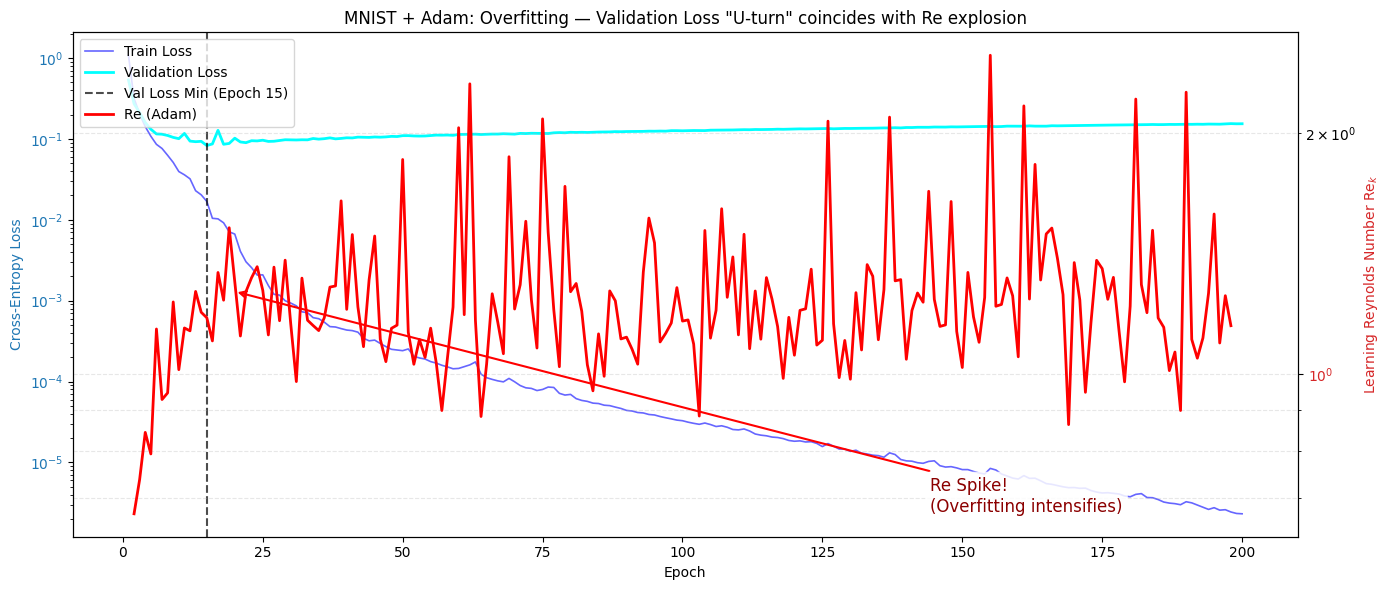

In [ ]:
# =============================================================================
# Re-draw the overfitting figure with annotation moved downward
# Uses existing variables from previous training (no re-training needed)
# =============================================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

# -------- Left axis: Loss --------
color_loss = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss', color=color_loss)
ax1.plot(range(1, len(train_loss2)+1), train_loss2,
         label='Train Loss', color='blue', alpha=0.6, linewidth=1.2)
ax1.plot(range(1, len(val_loss2)+1), val_loss2,
         label='Validation Loss', color='cyan', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.set_yscale('log')

# -------- Right axis: Re --------
ax2 = ax1.twinx()
color_Re = 'tab:red'
ax2.set_ylabel('Learning Reynolds Number Re$_k$', color=color_Re)
ax2.plot(Re_epochs2, Re2, label='Re (Adam)', color='red', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_Re)
ax2.set_yscale('log')

# -------- Mark the validation loss minimum (turning point) --------
ax1.axvline(x=min_val_epoch, color='black', linestyle='--', alpha=0.7,
            label=f'Val Loss Min (Epoch {min_val_epoch})')

# -------- Annotation: Re spike (moved to bottom-right) --------
# Use axes fraction coordinates so it stays in the lower-right corner
ax2.annotate('Re Spike!\n(Overfitting intensifies)',
             xy=(min_val_epoch + 5, Re2[min_val_epoch + 5] if min_val_epoch + 5 < len(Re2) else Re2[-1]),
             xycoords='data',               # arrow points to this data point
             xytext=(0.70, 0.05),           # text placed at (70% width, 5% height) of the axes
             textcoords='axes fraction',    # relative to the entire figure
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=12, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.85))

# -------- Title and layout --------
plt.title('MNIST + Adam: Overfitting — Validation Loss "U-turn" coincides with Re explosion')
fig.tight_layout()

# -------- Combine legends --------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

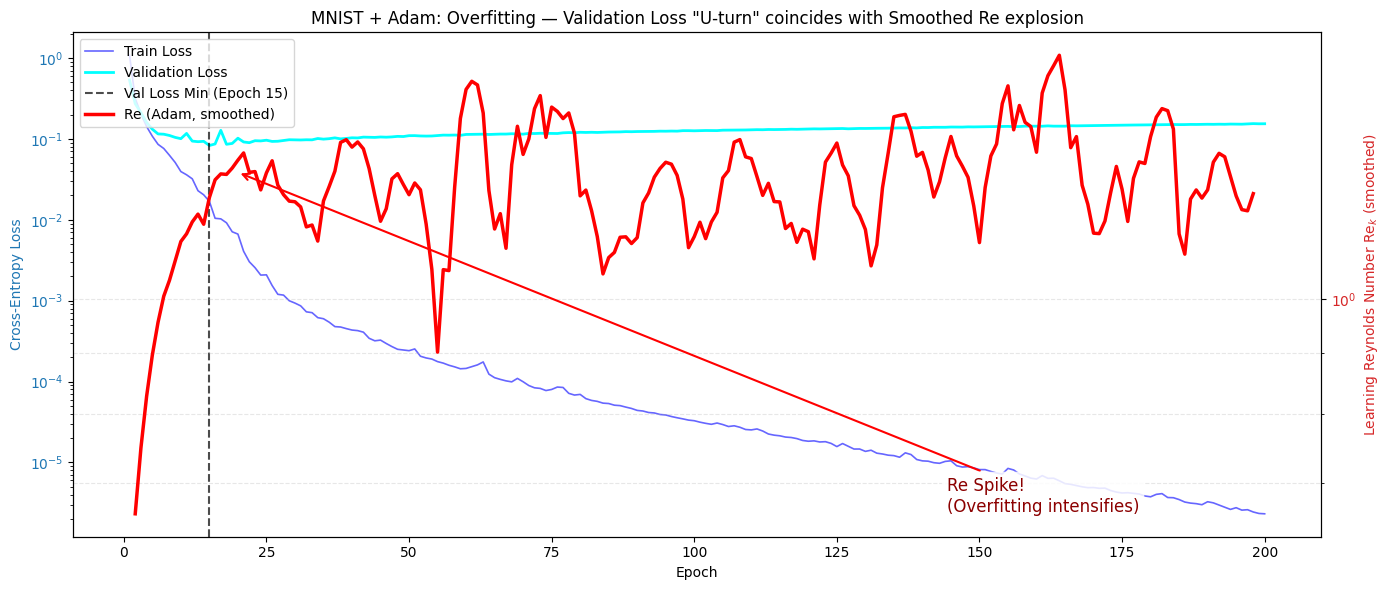


Re Smoothing Effect (quantitative)
Raw Re at min validation loss (Epoch 15): 1.175
Smoothed Re at min validation loss: 1.217
Raw Re max: 2.502
Smoothed Re max: 1.602


In [ ]:
# =============================================================================
# Overfitting figure with SMOOTHED Re (Moving Average)
# Uses existing variables from previous training
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ---------- 1. Smooth the Re curve using Savitzky–Golay filter ----------
# This preserves the sharp trend while removing high-frequency noise
window_length = 11   # must be odd; larger = smoother
polyorder = 3        # polynomial order for fitting

# Apply smoothing (only if Re2 has enough points)
if len(Re2) >= window_length:
    Re_smooth = savgol_filter(Re2, window_length, polyorder)
else:
    Re_smooth = Re2  # fallback to original

# ---------- 2. Plot ----------
fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis: Loss
color_loss = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss', color=color_loss)
ax1.plot(range(1, len(train_loss2)+1), train_loss2,
         label='Train Loss', color='blue', alpha=0.6, linewidth=1.2)
ax1.plot(range(1, len(val_loss2)+1), val_loss2,
         label='Validation Loss', color='cyan', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.set_yscale('log')

# Right axis: Smoothed Re
ax2 = ax1.twinx()
color_Re = 'tab:red'
ax2.set_ylabel('Learning Reynolds Number Re$_k$ (smoothed)', color=color_Re)
ax2.plot(Re_epochs2, Re_smooth, label='Re (Adam, smoothed)', color='red', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color_Re)
ax2.set_yscale('log')

# Mark turning point
ax1.axvline(x=min_val_epoch, color='black', linestyle='--', alpha=0.7,
            label=f'Val Loss Min (Epoch {min_val_epoch})')

# Annotation (moved to lower-right)
ax2.annotate('Re Spike!\n(Overfitting intensifies)',
             xy=(min_val_epoch + 5, Re_smooth[min_val_epoch + 5] if min_val_epoch + 5 < len(Re_smooth) else Re_smooth[-1]),
             xycoords='data',
             xytext=(0.70, 0.05),
             textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=12, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.85))

plt.title('MNIST + Adam: Overfitting — Validation Loss "U-turn" coincides with Smoothed Re explosion')
fig.tight_layout()

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

# ---------- 3. Print comparison ----------
print("\n" + "=" * 50)
print("Re Smoothing Effect (quantitative)")
print("=" * 50)
print(f"Raw Re at min validation loss (Epoch {min_val_epoch}): {Re2[min_val_epoch-2] if min_val_epoch >= 2 else Re2[0]:.3f}")
print(f"Smoothed Re at min validation loss: {Re_smooth[min_val_epoch-2] if min_val_epoch >= 2 else Re_smooth[0]:.3f}")
print(f"Raw Re max: {np.max(Re2):.3f}")
print(f"Smoothed Re max: {np.max(Re_smooth):.3f}")